# SIGNAL — Automated Traffic Violation Pipeline

Pipeline order:
1. Load video and vehicle model
2. Detect + track vehicles with ByteTrack
3. Detect traffic-light state
4. Detect robust stop-line crossing for each tracked vehicle
5. Automatically flag a vehicle only when it clearly crosses while the light is RED
6. Detect the number plate for the flagged vehicle
7. Crop and perspective-correct the plate
8. Enhance the plate image
9. Recognize characters with PARSeq (with OCR fallback)
10. Validate the plate text
11. Generate and store complete evidence

**No vehicle ID is hardcoded. Plate detection and OCR run only after a red-light violation has been confirmed.**


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict, deque
!pip install -q ultralytics
from ultralytics import YOLO
import torch
import json

print('Torch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.4/75.4 kB 5.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Torch: 2.10.0+cu128
CUDA available: True


In [2]:
# ==============================
# 1. VIDEO + VEHICLE MODEL
# ==============================

VIDEO_PATH = "/kaggle/input/datasets/farzadnekouei/license-plate-recognition-for-red-light-violation/traffic_video_modified.mp4"

VEHICLE_MODEL = "/kaggle/input/models/nadantikaap/yolov8pipeline/pytorch/default/1/best.pt"

vehicle_model = YOLO(VEHICLE_MODEL)

print("Video:", VIDEO_PATH)
print("Vehicle model:", VEHICLE_MODEL)
print("Classes:", vehicle_model.names)

Video: /kaggle/input/datasets/farzadnekouei/license-plate-recognition-for-red-light-violation/traffic_video_modified.mp4
Vehicle model: /kaggle/input/models/nadantikaap/yolov8pipeline/pytorch/default/1/best.pt
Classes: {0: 'person', 1: 'rider', 2: 'car', 3: 'bus', 4: 'truck', 5: 'bike', 6: 'motor', 7: 'traffic light', 8: 'traffic sign', 9: 'train'}


## 1. Load a calibration frame

The camera-specific geometry is calibrated once here. This is **scene configuration**, not identification of a violating vehicle.


Frame shape: (1012, 1920, 3)


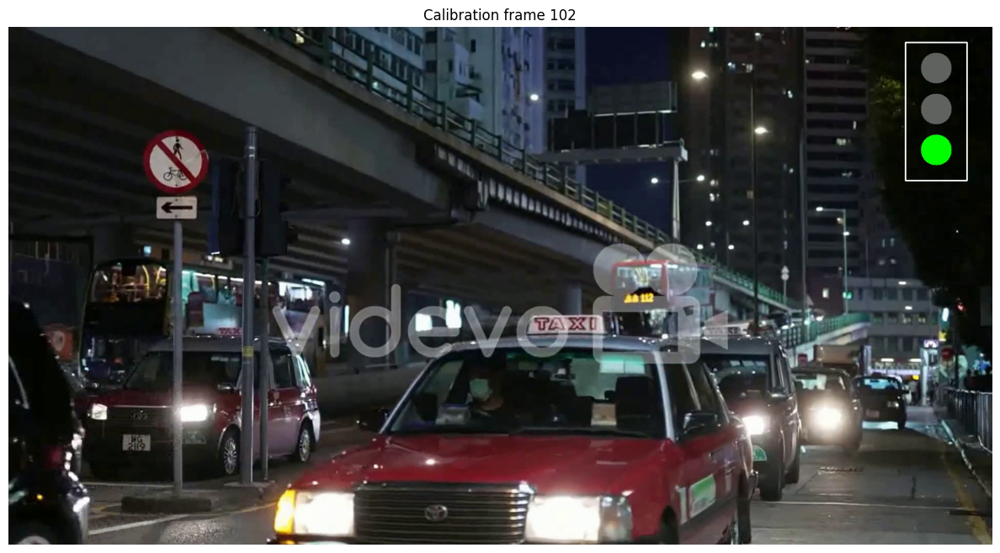

In [3]:
FRAME_NUMBER = 102

cap = cv2.VideoCapture(VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, FRAME_NUMBER)
ret, frame = cap.read()
cap.release()

if not ret:
    raise RuntimeError('Could not load calibration frame.')

print('Frame shape:', frame.shape)

plt.figure(figsize=(16, 8))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.title(f'Calibration frame {FRAME_NUMBER}')
plt.axis('off')
plt.show()


## 2. Scene calibration

Set these two regions for this fixed CCTV camera:
- `SIGNAL_ROI`: `(x1, y1, x2, y2)` around the traffic light
- `STOP_LINE`: two points defining the virtual stop line

These values stay fixed for this camera/video. The **vehicle ID is never specified**.


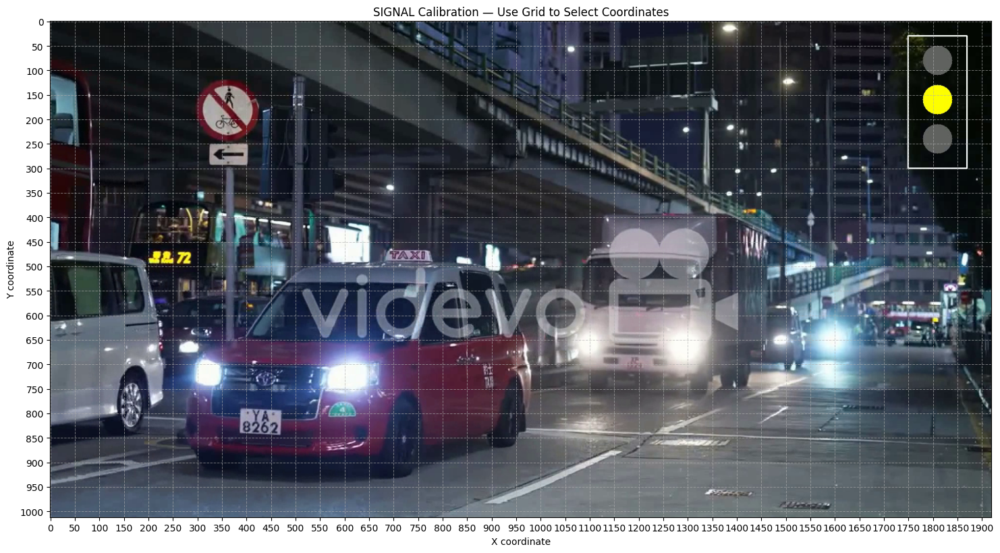

Frame size:
Width : 1920
Height: 1012


In [4]:
import cv2
import matplotlib.pyplot as plt

# Display a representative frame with coordinate grid
cap = cv2.VideoCapture(VIDEO_PATH)

cap.set(cv2.CAP_PROP_POS_FRAMES, 550)
ret, frame = cap.read()
cap.release()

if not ret:
    raise RuntimeError("Could not read calibration frame.")

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(18, 10))
plt.imshow(frame_rgb)

# Grid
plt.grid(
    True,
    linestyle="--",
    linewidth=0.7,
    alpha=0.6
)

# X-axis ticks
plt.xticks(range(0, frame.shape[1], 50))
plt.yticks(range(0, frame.shape[0], 50))

plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.title("SIGNAL Calibration — Use Grid to Select Coordinates")

plt.show()

print("Frame size:")
print("Width :", frame.shape[1])
print("Height:", frame.shape[0])

In [5]:
# ==============================
# SIGNAL CALIBRATION
# ==============================

# Traffic light ROI
TRAFFIC_LIGHT_ROI = (
    1750, 35,     # top-left (x, y)
    1850, 300    # bottom-right (x, y)
)

# Stop line
STOP_LINE = (
    (0, 800),   # left point
    (1900, 860)   # right point
)

STOP_LINE_Y = 700

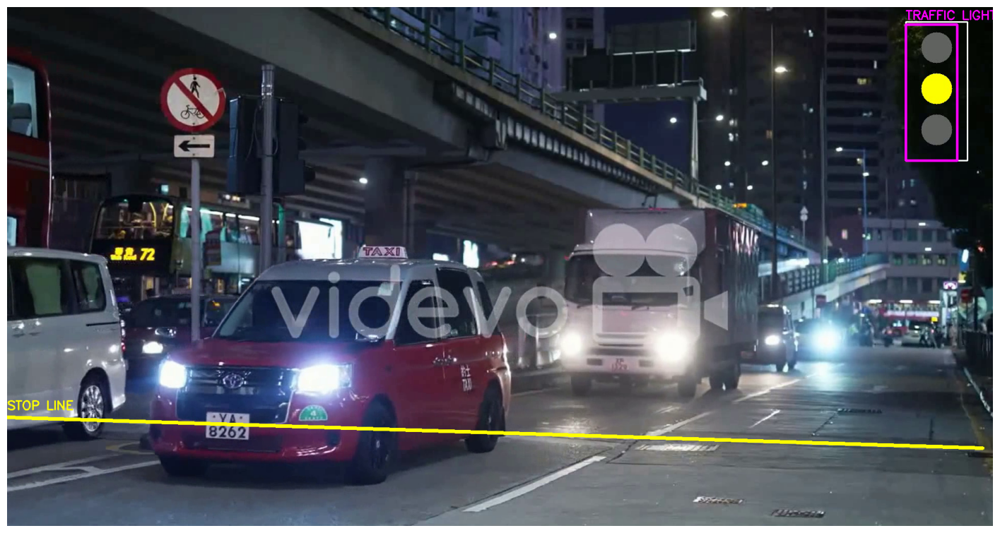

In [6]:
# ==============================
# DISPLAY CALIBRATION
# ==============================

calibration = frame.copy()

# Traffic light
x1, y1, x2, y2 = TRAFFIC_LIGHT_ROI

cv2.rectangle(
    calibration,
    (x1, y1),
    (x2, y2),
    (255, 0, 255),
    4
)

cv2.putText(
    calibration,
    "TRAFFIC LIGHT",
    (x1, y1 - 10),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.8,
    (255, 0, 255),
    2
)

# Stop line
cv2.line(
    calibration,
    STOP_LINE[0],
    STOP_LINE[1],
    (0, 255, 255),
    5
)

cv2.putText(
    calibration,
    "STOP LINE",
    (STOP_LINE[0][0], STOP_LINE[0][1] - 15),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.8,
    (0, 255, 255),
    2
)

plt.figure(figsize=(18, 10))
plt.imshow(cv2.cvtColor(calibration, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

## 3. Traffic-light state detector

The detector compares red, yellow, and green pixel evidence inside the configured traffic-light ROI. It returns `RED`, `YELLOW`, `GREEN`, or `UNKNOWN`.


In [7]:
def traffic_light_state(image, roi):
    x1, y1, x2, y2 = roi
    crop = image[y1:y2, x1:x2]
    if crop.size == 0:
        return 'UNKNOWN', 0.0, 0.0, 0.0

    hsv = cv2.cvtColor(crop, cv2.COLOR_BGR2HSV)

    # Red wraps around the HSV hue boundary.
    red1 = cv2.inRange(hsv, np.array([0, 100, 100]), np.array([10, 255, 255]))
    red2 = cv2.inRange(hsv, np.array([170, 100, 100]), np.array([180, 255, 255]))
    red_mask = cv2.bitwise_or(red1, red2)
    
    yellow_mask = cv2.inRange(hsv,np.array([15, 80, 80]), np.array([35, 255, 255]))
    
    green_mask = cv2.inRange(hsv, np.array([35, 80, 80]), np.array([90, 255, 255]))

    red_score = float(np.count_nonzero(red_mask)) / red_mask.size
    yellow_score = float(np.count_nonzero(yellow_mask)) / yellow_mask.size
    green_score = float(np.count_nonzero(green_mask)) / green_mask.size

    threshold = 0.003
    if red_score > green_score and red_score > yellow_score and red_score > threshold:
        return 'RED', red_score, yellow_score, green_score
    
    if yellow_score > red_score and yellow_score > green_score and yellow_score > threshold:
        return 'YELLOW', red_score, yellow_score, green_score
    
    if green_score > red_score and green_score > yellow_score and green_score > threshold:
        return 'GREEN', red_score, yellow_score, green_score
    
    return 'UNKNOWN', red_score, yellow_score, green_score

state, red_score, yellow_score, green_score = traffic_light_state(
    frame, TRAFFIC_LIGHT_ROI
)

print(
    'Signal:', state,
    '| red:', round(red_score, 4),
    '| yellow:', round(yellow_score, 4),
    '| green:', round(green_score, 4)
)


Signal: YELLOW | red: 0.0 | yellow: 0.1058 | green: 0.0002


## 4. Vehicle tracking + robust red-light violation detection

A vehicle is considered a violation only when the tracked vehicle:
1. has enough tracking history,
2. was clearly before the stop line,
3. moves clearly beyond the line (not just touching it),
4. remains beyond the line for confirmation, and
5. was crossing while RED was already confirmed.

The margin is intentional: the previous version flagged vehicles whose bottom-center was only 0–8 px beyond the line, which is usually just bounding-box/line-contact noise.


In [8]:
# ==============================
# VEHICLE TRACKING + RED-LIGHT VIOLATION DETECTION
# ==============================

VEHICLE_CLASSES = [2, 3, 4]   # car, bus, truck
CONF = 0.25
IMGSZ = 1280

# Tracking
MIN_TRACK_FRAMES = 5
TRACK_HISTORY_LEN = 30

# Crossing detection
PRE_CROSS_MARGIN = 5          # vehicle must have been slightly before line
POST_CROSS_MARGIN = 0         # crossing happens when point reaches/passes line
MAX_CROSSING_JUMP = 120        # reject impossible jumps
MIN_DOWNWARD_MOTION = 2        # small forward movement is enough

# Signal detection
SIGNAL_HISTORY_LEN = 7
MIN_RED_FRAMES = 3             # majority of recent frames should be RED

MAX_VIOLATIONS = 20


def line_y_at_x(x, p1, p2):
    x1, y1 = p1
    x2, y2 = p2

    if x2 == x1:
        return float(min(y1, y2))

    return float(
        y1 + (y2 - y1) * ((x - x1) / (x2 - x1))
    )


def signed_line_distance(point, p1, p2):
    """
    Negative = before/above stop line
    Positive = after/below stop line
    """

    x, y = point

    return float(
        y - line_y_at_x(x, p1, p2)
    )


# =================================
# Tracking storage
# =================================

track_history = defaultdict(
    lambda: deque(maxlen=TRACK_HISTORY_LEN)
)

track_seen_frames = defaultdict(int)

flagged_ids = set()

violations = []
violation_frames = []

# Store signal information for recent frames
signal_history = deque(
    maxlen=SIGNAL_HISTORY_LEN
)


# =================================
# Run YOLO tracking
# =================================

results = vehicle_model.track(
    source=VIDEO_PATH,
    tracker='bytetrack.yaml',
    stream=True,
    persist=True,
    conf=CONF,
    imgsz=IMGSZ,
    classes=VEHICLE_CLASSES,
    verbose=False
)


for frame_number, result in enumerate(results):

    current_frame = result.orig_img.copy()

    # =================================
    # 1. Detect traffic-light state
    # =================================

    signal, red_score, yellow_score, green_score = (
        traffic_light_state(
            current_frame,
            TRAFFIC_LIGHT_ROI
        )
    )

    # Save signal for this frame
    signal_history.append({
        'frame': frame_number,
        'signal': signal,
        'red_score': red_score,
        'yellow_score': yellow_score,
        'green_score': green_score
    })


    # =================================
    # 2. Check recent signal stability
    # =================================

    recent_signals = [
        x['signal']
        for x in signal_history
    ]

    recent_red_count = sum(
        s == 'RED'
        for s in recent_signals
    )

    red_confirmed = (
        recent_red_count >= MIN_RED_FRAMES
    )


    # =================================
    # 3. Get tracked vehicles
    # =================================

    if result.boxes.id is None:
        continue


    boxes = result.boxes.xyxy.cpu().numpy()

    ids = (
        result.boxes.id
        .cpu()
        .numpy()
        .astype(int)
    )

    classes = (
        result.boxes.cls
        .cpu()
        .numpy()
        .astype(int)
    )


    # =================================
    # 4. Process every tracked vehicle
    # =================================

    for box, track_id, class_id in zip(
        boxes,
        ids,
        classes
    ):

        track_id = int(track_id)

        x1, y1, x2, y2 = map(
            int,
            box
        )


        # Bottom-center of vehicle
        bottom_center = (
            (x1 + x2) // 2,
            y2
        )


        history = track_history[track_id]

        previous_points = list(history)

        track_seen_frames[track_id] += 1


        # Current signed distance from stop line
        current_dist = signed_line_distance(
            bottom_center,
            STOP_LINE[0],
            STOP_LINE[1]
        )


        # Save current point
        history.append(bottom_center)


        # Already detected
        if track_id in flagged_ids:
            continue


        # Need enough history to understand movement
        if track_seen_frames[track_id] < MIN_TRACK_FRAMES:
            continue


        if len(previous_points) < 1:
            continue


        # =================================
        # 5. Detect ACTUAL line crossing
        # =================================

        previous_point = previous_points[-1]

        previous_dist = signed_line_distance(
            previous_point,
            STOP_LINE[0],
            STOP_LINE[1]
        )


        # Movement between frames
        downward_motion = (
            bottom_center[1]
            - previous_point[1]
        )


        distance_jump = (
            current_dist
            - previous_dist
        )


        # Vehicle must have previously been
        # clearly BEFORE the stop line.
        was_before_line = (
            previous_dist <= -PRE_CROSS_MARGIN
        )


        # Vehicle is now on/after the line.
        crossed_line = (
            current_dist >= POST_CROSS_MARGIN
        )


        # Prevent crazy detector jumps.
        reasonable_jump = (
            distance_jump <= MAX_CROSSING_JUMP
        )


        # Vehicle should be moving forward.
        moving_forward = (
            downward_motion >= MIN_DOWNWARD_MOTION
        )


        crossing_event = (
            was_before_line
            and crossed_line
            and reasonable_jump
            and moving_forward
        )


        if not crossing_event:
            continue


        # =================================
        # 6. IMPORTANT:
        #    Check signal AT CROSSING
        # =================================

        # Look at the most recent signal frames.
        crossing_signal_history = list(
            signal_history
        )[-SIGNAL_HISTORY_LEN:]


        crossing_red_count = sum(
            x['signal'] == 'RED'
            for x in crossing_signal_history
        )


        crossing_red_confirmed = (
            crossing_red_count >= MIN_RED_FRAMES
        )


        # =================================
        # 7. NOT RED = legal crossing
        # =================================

        if not crossing_red_confirmed:
            continue


        # =================================
        # 8. RED + actual crossing
        #    = VIOLATION
        # =================================

        flagged_ids.add(track_id)


        # Use current signal scores
        current_signal_data = signal_history[-1]


        annotated = current_frame.copy()


        # Stop line
        cv2.line(
            annotated,
            STOP_LINE[0],
            STOP_LINE[1],
            (0, 255, 255),
            5
        )


        # Traffic-light ROI
        sx1, sy1, sx2, sy2 = (
            TRAFFIC_LIGHT_ROI
        )


        cv2.rectangle(
            annotated,
            (sx1, sy1),
            (sx2, sy2),
            (255, 0, 255),
            4
        )


        # Vehicle
        cv2.rectangle(
            annotated,
            (x1, y1),
            (x2, y2),
            (0, 0, 255),
            5
        )


        # Violation label
        cv2.putText(
            annotated,
            f'RED-LIGHT VIOLATION | ID {track_id}',
            (
                max(20, x1),
                max(45, y1 - 15)
            ),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.0,
            (0, 0, 255),
            3
        )


        cv2.putText(
            annotated,
            f'Frame {frame_number} | RED at crossing',
            (25, 45),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.9,
            (0, 0, 255),
            3
        )


        # =================================
        # 9. Save violation
        # =================================

        violation = {
            'type': 'red_light',

            'frame': int(frame_number),

            'crossing_frame': int(frame_number),

            'track_id': int(track_id),

            'class_id': int(class_id),

            'bbox': [
                x1,
                y1,
                x2,
                y2
            ],

            'signal': 'RED',

            'red_score': float(
                current_signal_data['red_score']
            ),

            'yellow_score': float(
                current_signal_data['yellow_score']
            ),

            'green_score': float(
                current_signal_data['green_score']
            ),

            'red_frames_in_history': int(
                crossing_red_count
            ),

            'track_frames_before_crossing': int(
                track_seen_frames[track_id]
            ),

            'previous_line_distance_px': float(
                previous_dist
            ),

            'crossing_line_distance_px': float(
                current_dist
            )
        }


        violations.append(
            violation
        )

        violation_frames.append(
            annotated
        )


        # =================================
        # 10. Stop after MAX_VIOLATIONS
        # =================================

        if len(violations) >= MAX_VIOLATIONS:
            break


    if len(violations) >= MAX_VIOLATIONS:
        break


# =================================
# RESULTS
# =================================

print(
    'Automatic violations detected:',
    len(violations)
)


for v in violations:
    print(v)

requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 335ms
Prepared 1 package in 95ms
Installed 1 package in 5ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

Automatic violations detected: 2
{'type': 'red_light', 'frame': 334, 'crossing_frame': 334, 'track_id': 249, 'class_id': 2, 'bbox': [331, 582, 600, 823], 'signal': 'RED', 'red_score': 0.10766037735849057, 'yellow_score': 0.0, 'green_score': 0.0003018867924528302, 'red_frames_in_history': 7, 'track_frames_before_crossing': 15, 'previous_line_distance_px': -8.799999999999955, 'crossing_line_distance_px': 8.315789473684163}
{'type': 'red_light', 'frame': 638, 'crossing_frame': 638, 'track_id': 436, 'class_id': 4, 'bbox': [875, 223, 1454, 848], 'signal': 'RED', 'red_score': 0.10777358490566037, 'yellow_score': 0.0002641509433962264, 'green

## 5. Display the exact violation frame(s)


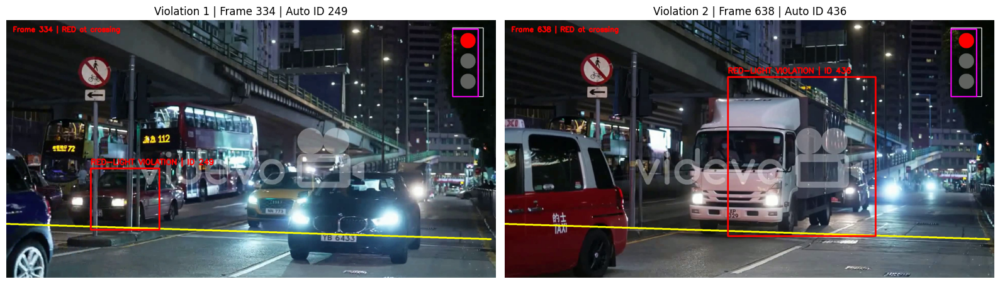

In [9]:
if not violation_frames:
    print('No violation was detected with the current scene calibration.')
    print('If the calibration overlay is correct, inspect the signal detector and stop-line crossing thresholds.')
else:
    cols = min(2, len(violation_frames))
    rows = int(np.ceil(len(violation_frames) / cols))
    plt.figure(figsize=(16, 7 * rows))

    for i, image in enumerate(violation_frames):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.title(
            f"Violation {i + 1} | Frame {violations[i]['frame']} | "
            f"Auto ID {violations[i]['track_id']}"
        )
        plt.axis('off')

    plt.tight_layout()
    plt.show()


## 6. Save automatic violation results

This is the handoff point for the next pipeline stage. **Do not run plate detection yet.**


In [10]:
with open('/kaggle/working/violations.json', 'w') as f:
    json.dump(violations, f, indent=2)

print('Saved:', '/kaggle/working/violations.json')


Saved: /kaggle/working/violations.json


## 7. Number-plate detection

Only confirmed violations are sent to the plate detector. The detector is loaded from the available Kaggle model files, or you can set `PLATE_MODEL_PATH` explicitly.


In [11]:
# ==============================
# NUMBER-PLATE DETECTION
# ==============================

import os
import re
from PIL import Image

PLATE_MODEL_PATH = "/kaggle/input/models/mohamedmohy10/automatic-license-plate-recognition-yolov8n/other/default/3/alpr_yolov8n_640.pt"

PLATE_CONF = 0.20
PLATE_IMGSZ = 640

plate_model = YOLO(PLATE_MODEL_PATH)

print("Plate model:", PLATE_MODEL_PATH)
print("Plate model classes:", plate_model.names)


def detect_plate(frame, vehicle_bbox):
    """Detect the best plate inside one violating vehicle's bounding box."""
    h, w = frame.shape[:2]
    x1, y1, x2, y2 = map(int, vehicle_bbox)

    pad_x = int(0.05 * max(1, x2 - x1))
    pad_y = int(0.08 * max(1, y2 - y1))

    vx1 = max(0, x1 - pad_x)
    vy1 = max(0, y1 - pad_y)
    vx2 = min(w, x2 + pad_x)
    vy2 = min(h, y2 + pad_y)

    vehicle_crop = frame[vy1:vy2, vx1:vx2]

    if vehicle_crop.size == 0:
        return None

    result = plate_model.predict(
        source=vehicle_crop,
        conf=PLATE_CONF,
        imgsz=PLATE_IMGSZ,
        verbose=False
    )[0]

    if result.boxes is None or len(result.boxes) == 0:
        return None

    boxes = result.boxes.xyxy.cpu().numpy()
    confs = result.boxes.conf.cpu().numpy()

    best = int(np.argmax(confs))

    px1, py1, px2, py2 = map(int, boxes[best])
    score = float(confs[best])

    px1, px2 = px1 + vx1, px2 + vx1
    py1, py2 = py1 + vy1, py2 + vy1

    px1, py1 = max(0, px1), max(0, py1)
    px2, py2 = min(w, px2), min(h, py2)

    plate_crop = frame[py1:py2, px1:px2].copy()

    if plate_crop.size == 0:
        return None

    return {
        "bbox": [px1, py1, px2, py2],
        "confidence": score,
        "crop": plate_crop
    }

Plate model: /kaggle/input/models/mohamedmohy10/automatic-license-plate-recognition-yolov8n/other/default/3/alpr_yolov8n_640.pt
Plate model classes: {0: 'license_plate'}


## 8. Plate crop + perspective correction

The detected plate is isolated first. A quadrilateral is estimated from the plate edges; if no reliable quadrilateral is found, the rectangular detector crop is used safely as a fallback.


In [12]:
# ==============================
# PLATE GEOMETRY
# ==============================

def order_points(points):
    pts = np.asarray(points, dtype=np.float32)
    s = pts.sum(axis=1)
    d = np.diff(pts, axis=1).ravel()
    return np.array([
        pts[np.argmin(s)],   # top-left
        pts[np.argmin(d)],   # top-right
        pts[np.argmax(s)],   # bottom-right
        pts[np.argmax(d)],   # bottom-left
    ], dtype=np.float32)


def four_point_transform(image, points):
    rect = order_points(points)
    tl, tr, br, bl = rect

    width_a = np.linalg.norm(br - bl)
    width_b = np.linalg.norm(tr - tl)
    height_a = np.linalg.norm(tr - br)
    height_b = np.linalg.norm(tl - bl)

    max_width = max(32, int(round(max(width_a, width_b))))
    max_height = max(16, int(round(max(height_a, height_b))))

    dst = np.array([
        [0, 0],
        [max_width - 1, 0],
        [max_width - 1, max_height - 1],
        [0, max_height - 1],
    ], dtype=np.float32)

    matrix = cv2.getPerspectiveTransform(rect, dst)
    return cv2.warpPerspective(image, matrix, (max_width, max_height))


def perspective_correct_plate(plate_crop):
    """Find a strong quadrilateral edge and rectify it; otherwise return the crop."""
    if plate_crop is None or plate_crop.size == 0:
        return None

    gray = cv2.cvtColor(plate_crop, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(gray, 50, 150)

    contours, _ = cv2.findContours(edges, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    h, w = gray.shape
    image_area = float(h * w)
    best = None
    best_score = 0.0

    for contour in contours:
        area = cv2.contourArea(contour)
        if area < 0.10 * image_area:
            continue
        perimeter = cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(contour, 0.04 * perimeter, True)
        if len(approx) != 4 or not cv2.isContourConvex(approx):
            continue

        x, y, cw, ch = cv2.boundingRect(approx)
        aspect = cw / max(ch, 1)
        if aspect < 1.5 or aspect > 8.0:
            continue

        score = area / image_area
        if score > best_score:
            best_score = score
            best = approx.reshape(4, 2)

    if best is None:
        return plate_crop.copy()

    return four_point_transform(plate_crop, best)


## 9. Image enhancement

Brightness/contrast normalization, denoising, sharpening and upscaling improve OCR without changing the detected plate identity.


In [13]:
# ==============================
# IMAGE ENHANCEMENT
# ==============================

def enhance_plate(plate):
    if plate is None or plate.size == 0:
        return None

    # Upscale before OCR so small characters occupy more pixels.
    h, w = plate.shape[:2]
    scale = max(2.0, min(4.0, 160.0 / max(1, h)))
    up = cv2.resize(plate, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)

    # Denoise while preserving edges.
    denoised = cv2.fastNlMeansDenoisingColored(up, None, 5, 5, 7, 21)

    # CLAHE improves local contrast under uneven illumination.
    lab = cv2.cvtColor(denoised, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    enhanced = cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2BGR)

    # Mild unsharp mask.
    blur = cv2.GaussianBlur(enhanced, (0, 0), 1.2)
    sharpened = cv2.addWeighted(enhanced, 1.35, blur, -0.35, 0)
    return sharpened


## 10. Character recognition — PARSeq / OCR fallback

PARSeq is the primary recognizer. If the PARSeq package/model cannot be loaded in the current Kaggle environment, the code falls back to EasyOCR so the rest of the pipeline can still run.


In [14]:
!pip install -q lmdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 344.7/344.7 kB 6.1 MB/s eta 0:00:00:00:01


In [27]:
# ==============================
# OCR — EASYOCR
# ==============================

!pip install -q easyocr

import easyocr
import re
import numpy as np
import torch

ocr_reader = easyocr.Reader(
    ["en"],
    gpu=torch.cuda.is_available()
)

ocr_backend = "EasyOCR"

print("OCR backend:", ocr_backend)


def clean_plate_text(text):
    text = str(text).upper()
    return re.sub(r"[^A-Z0-9]", "", text)





def recognize_plate(plate_image):
    if plate_image is None or plate_image.size == 0:
        return "", 0.0, "NONE"

    # --------------------------------
    # 1. UPSCALE THE PLATE
    # --------------------------------
    img = cv2.resize(
        plate_image,
        None,
        fx=5,
        fy=5,
        interpolation=cv2.INTER_CUBIC
    )

    # --------------------------------
    # 2. CREATE OCR VERSIONS
    # --------------------------------
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )
    contrast = clahe.apply(gray)

    # Light sharpening
    blur = cv2.GaussianBlur(contrast, (0, 0), 1)
    sharp = cv2.addWeighted(
        contrast, 1.5,
        blur, -0.5,
        0
    )

    _, binary = cv2.threshold(
        sharp,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    versions = [
        img,
        gray,
        contrast,
        sharp,
        binary
    ]

    # --------------------------------
    # 3. OCR EACH VERSION SEPARATELY
    # --------------------------------
    candidates = []

    for version in versions:

        results = ocr_reader.readtext(
            version,
            detail=1,
            paragraph=False,
            allowlist="ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"
        )

        if not results:
            continue

        # Keep reasonably confident detections
        results = [
            r for r in results
            if float(r[2]) >= 0.15
        ]

        if not results:
            continue

        # Reading order
        results.sort(
            key=lambda r: (
                np.mean([p[1] for p in r[0]]),
                np.mean([p[0] for p in r[0]])
            )
        )

        text = clean_plate_text(
            "".join(r[1] for r in results)
        )

        confidence = float(
            np.mean([float(r[2]) for r in results])
        )

        if text:
            candidates.append(
                (text, confidence)
            )

    # --------------------------------
    # 4. CHOOSE ONE RESULT
    # --------------------------------
    if not candidates:
        return "", 0.0, "EasyOCR"

    # Prefer plausible plate lengths,
    # then confidence.
    candidates.sort(
        key=lambda x: (
            1 if 5 <= len(x[0]) <= 10 else 0,
            x[1]
        ),
        reverse=True
    )

    best_text, best_conf = candidates[0]

    return best_text, best_conf, "EasyOCR"

OCR backend: EasyOCR


## 11. Plate validation

Validation rejects obviously unusable OCR strings before evidence is generated. It is intentionally generic rather than hardcoding a single vehicle ID or plate value.


In [28]:
# ==============================
# PLATE VALIDATION
# ==============================

MIN_PLATE_LENGTH = 6
MAX_PLATE_LENGTH = 12
MIN_OCR_CONFIDENCE = 0.30

# Generic alphanumeric registration format.
PLATE_PATTERN = re.compile(r"^[A-Z0-9]{6,12}$")


def validate_plate(text, confidence):
    text = clean_plate_text(text)
    checks = {
        "non_empty": bool(text),
        "length_ok": MIN_PLATE_LENGTH <= len(text) <= MAX_PLATE_LENGTH,
        "alphanumeric": bool(PLATE_PATTERN.fullmatch(text)),
        "confidence_ok": float(confidence) >= MIN_OCR_CONFIDENCE,
    }
    return {
        "text": text,
        "valid": all(checks.values()),
        "checks": checks,
    }


## 12. Evidence generation & storage

For every confirmed violation, store the original violation frame, annotated evidence frame, plate crop, corrected plate, enhanced plate and a JSON record containing the full audit trail.


PLATE PROCESSING — VIOLATION 1 | FRAME 334 | TRACK 249
STAGE 1 — PLATE DETECTION: NO PLATE DETECTED


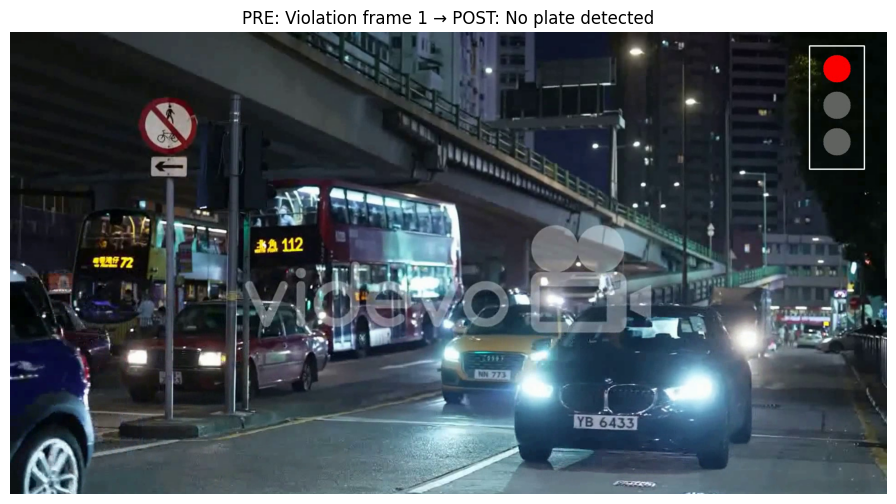

PLATE PROCESSING — VIOLATION 2 | FRAME 638 | TRACK 436
STAGE 1 — PLATE DETECTION | confidence=0.435


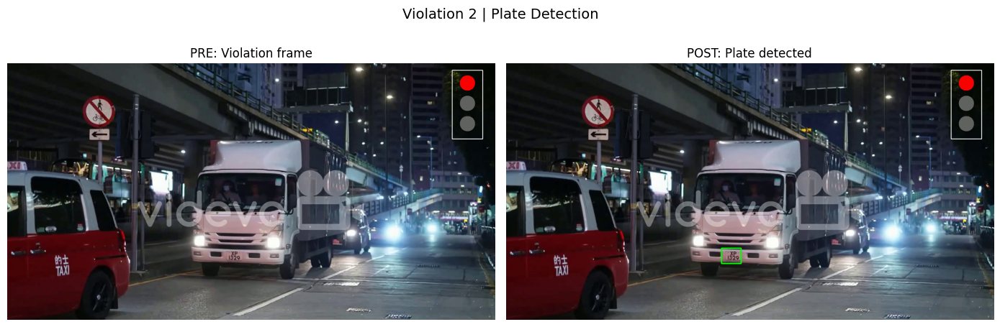

STAGE 2 — PERSPECTIVE CORRECTION


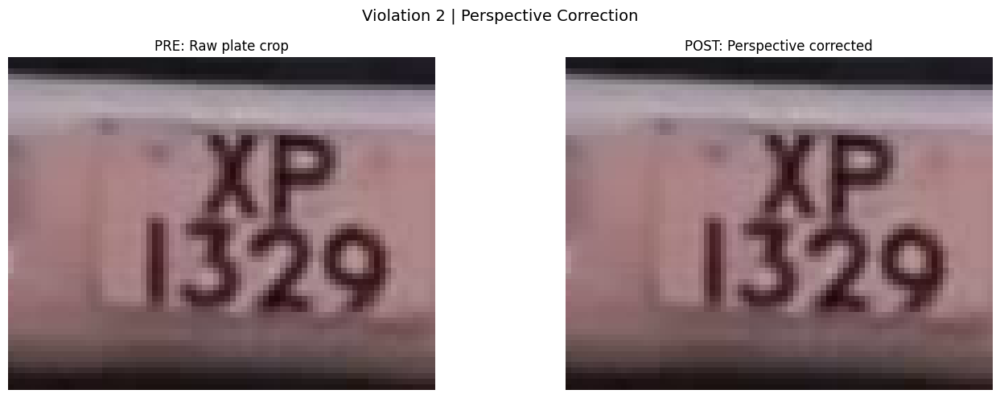

STAGE 3 — IMAGE ENHANCEMENT


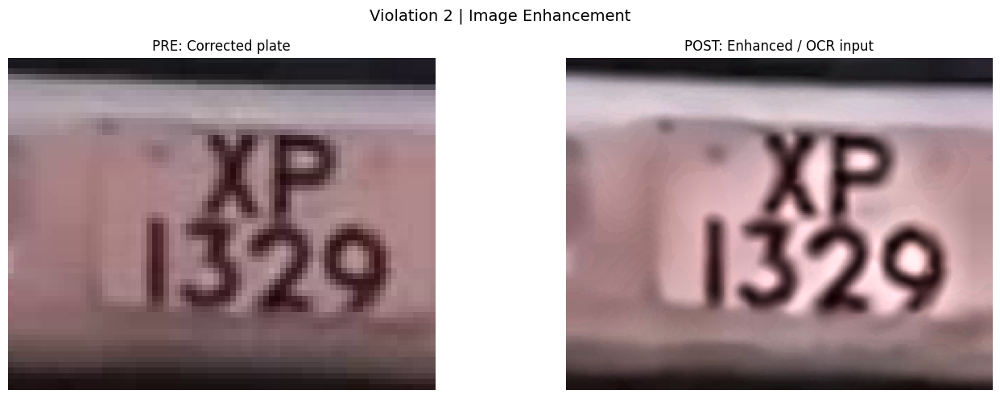

STAGE 4 — OCR


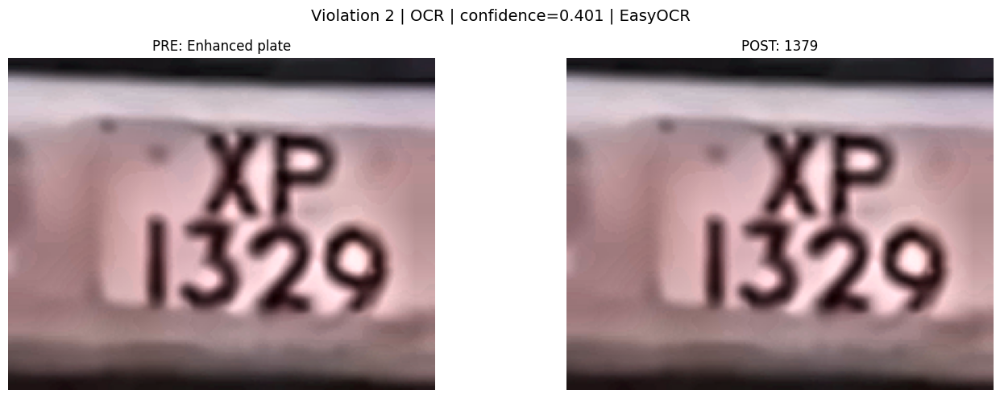

STAGE 5 — VALIDATION


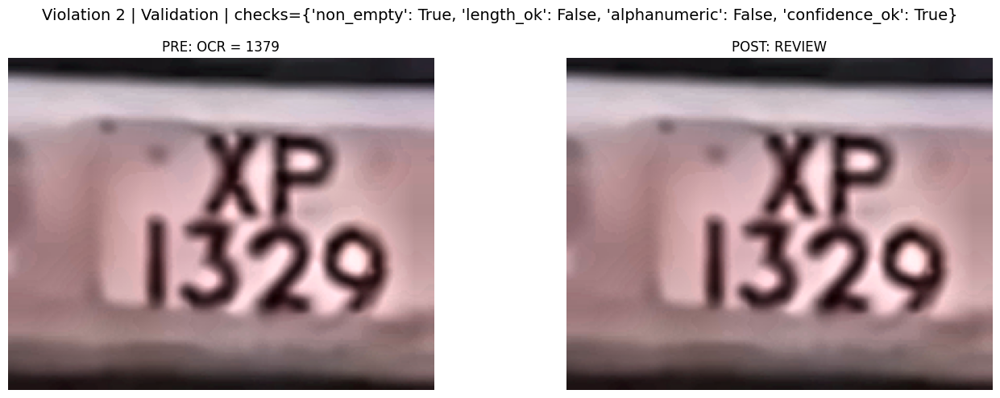

FINAL RESULT: 1379 | confidence=0.401 | REVIEW

PLATE PROCESSING COMPLETE
Violations processed: 2


In [29]:

# Display helper used by every PRE/POST stage.
def _show_img(ax, image, title):
    if image is None or getattr(image, "size", 0) == 0:
        ax.text(0.5, 0.5, "NO OUTPUT", ha="center", va="center", fontsize=12)
        ax.axis("off")
        ax.set_title(title)
        return
    if len(image.shape) == 3:
        ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    else:
        ax.imshow(image, cmap="gray")
    ax.axis("off")
    ax.set_title(title)

# ==============================
# EVIDENCE GENERATION + PLATE PROCESSING
# ==============================
# This cell processes EVERY confirmed violation and immediately displays
# the PRE -> POST result of each plate-processing stage.

OUTPUT_DIR = Path("/kaggle/working/signal_evidence")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def read_video_frame(video_path, frame_number):
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_number))
    ok, image = cap.read()
    cap.release()
    return image if ok else None


def save_image(path, image):
    if image is not None and image.size:
        cv2.imwrite(str(path), image)


def show_stage(pre, post=None, pre_title="PRE", post_title="POST", title=""):
    """Display the output of one plate-processing stage immediately."""
    if post is None:
        post = pre
        post_title = "OUTPUT"

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    _show_img(axes[0], pre, pre_title)
    _show_img(axes[1], post, post_title)
    if title:
        fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


def build_evidence_frame(frame, vehicle_bbox, plate_bbox, plate_text, plate_valid):
    out = frame.copy()
    x1, y1, x2, y2 = map(int, vehicle_bbox)
    cv2.rectangle(out, (x1, y1), (x2, y2), (0, 0, 255), 4)

    if plate_bbox is not None:
        px1, py1, px2, py2 = map(int, plate_bbox)
        cv2.rectangle(out, (px1, py1), (px2, py2), (0, 255, 0), 4)

    label = f"PLATE: {plate_text or 'NOT READ'} | {'VALID' if plate_valid else 'REVIEW'}"
    cv2.putText(out, "RED-LIGHT VIOLATION", (25, 45),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 255), 3)
    cv2.putText(out, label, (25, 85),
                cv2.FONT_HERSHEY_SIMPLEX, 0.85, (0, 255, 0), 2)
    return out


# Process only the violations produced by the previous stage.
plate_results = []

for index, violation in enumerate(violations, start=1):
    frame_number = int(violation["frame"])
    frame = read_video_frame(VIDEO_PATH, frame_number)

    if frame is None:
        print(f"Skipping violation {index}: frame {frame_number} could not be read")
        continue

    print("=" * 80)
    print(f"PLATE PROCESSING — VIOLATION {index} | FRAME {frame_number} | "
          f"TRACK {violation.get('track_id')}")
    print("=" * 80)

    plate = detect_plate(frame, violation["bbox"])

    record = {
        **violation,
        "plate_detection": None,
        "processing": {"pre": None, "post": None},
        "ocr": None,
        "validation": None,
        "evidence": {},
    }

    evidence_dir = OUTPUT_DIR / f"violation_{index:03d}_frame_{frame_number:06d}"
    evidence_dir.mkdir(parents=True, exist_ok=True)

    save_image(evidence_dir / "original_violation_frame.jpg", frame)

    # --------------------------------------------------
    # STAGE 1 — PLATE DETECTION
    # --------------------------------------------------
    if plate is None:
        record["plate_detection"] = {"detected": False}

        print("STAGE 1 — PLATE DETECTION: NO PLATE DETECTED")
        plt.figure(figsize=(12, 6))
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        plt.title(f"PRE: Violation frame {index} → POST: No plate detected")
        plt.axis("off")
        plt.show()

        evidence_frame = build_evidence_frame(
            frame, violation["bbox"], None, "", False
        )
        save_image(evidence_dir / "evidence_frame.jpg", evidence_frame)

        record["evidence"] = {
            "directory": str(evidence_dir),
            "original_frame": str(evidence_dir / "original_violation_frame.jpg"),
            "evidence_frame": str(evidence_dir / "evidence_frame.jpg"),
        }
        plate_results.append(record)
        continue

    record["plate_detection"] = {
        "detected": True,
        "bbox": plate["bbox"],
        "confidence": plate["confidence"],
    }

    raw_plate = plate["crop"]

    # Annotated frame showing what was detected.
    annotated = frame.copy()
    px1, py1, px2, py2 = map(int, plate["bbox"])
    cv2.rectangle(annotated, (px1, py1), (px2, py2), (0, 255, 0), 4)

    print(f"STAGE 1 — PLATE DETECTION | confidence={plate['confidence']:.3f}")
    show_stage(
        frame, annotated,
        "PRE: Violation frame",
        "POST: Plate detected",
        f"Violation {index} | Plate Detection"
    )

    # --------------------------------------------------
    # STAGE 2 — PERSPECTIVE CORRECTION
    # --------------------------------------------------
    corrected_plate = perspective_correct_plate(raw_plate)

    print("STAGE 2 — PERSPECTIVE CORRECTION")
    show_stage(
        raw_plate, corrected_plate,
        "PRE: Raw plate crop",
        "POST: Perspective corrected",
        f"Violation {index} | Perspective Correction"
    )

    # --------------------------------------------------
    # STAGE 3 — IMAGE ENHANCEMENT
    # --------------------------------------------------
    enhanced_plate = enhance_plate(corrected_plate)

    print("STAGE 3 — IMAGE ENHANCEMENT")
    show_stage(
        corrected_plate, enhanced_plate,
        "PRE: Corrected plate",
        "POST: Enhanced / OCR input",
        f"Violation {index} | Image Enhancement"
    )

    # Save all intermediate outputs.
    record["processing"] = {
        "pre": {
            "plate_crop": str(evidence_dir / "plate_crop.jpg")
        },
        "post": {
            "perspective_corrected": str(evidence_dir / "plate_corrected.jpg"),
            "enhanced": str(evidence_dir / "plate_enhanced.jpg"),
        },
    }

    save_image(evidence_dir / "plate_crop.jpg", raw_plate)
    save_image(evidence_dir / "plate_corrected.jpg", corrected_plate)
    save_image(evidence_dir / "plate_enhanced.jpg", enhanced_plate)

    # Also keep these paths in evidence for the later display cells.
    # --------------------------------------------------
    # STAGE 4 — OCR
    # --------------------------------------------------
    text, ocr_confidence, backend = recognize_plate(enhanced_plate)

    record["ocr"] = {
        "text": text,
        "confidence": ocr_confidence,
        "backend": backend,
    }

    print("STAGE 4 — OCR")
    show_stage(
        enhanced_plate, enhanced_plate,
        "PRE: Enhanced plate",
        f"POST: {text or 'NOT READ'}",
        f"Violation {index} | OCR | confidence={ocr_confidence:.3f} | {backend}"
    )

    # --------------------------------------------------
    # STAGE 5 — VALIDATION
    # --------------------------------------------------
    validation = validate_plate(text, ocr_confidence)
    record["validation"] = validation

    status = "VALID" if validation["valid"] else "REVIEW"

    print("STAGE 5 — VALIDATION")
    show_stage(
        enhanced_plate, enhanced_plate,
        f"PRE: OCR = {text or 'NOT READ'}",
        f"POST: {status}",
        f"Violation {index} | Validation | checks={validation['checks']}"
    )

    # --------------------------------------------------
    # FINAL EVIDENCE
    # --------------------------------------------------
    evidence_frame = build_evidence_frame(
        frame,
        violation["bbox"],
        plate["bbox"],
        text,
        validation["valid"],
    )
    save_image(evidence_dir / "evidence_frame.jpg", evidence_frame)

    record["evidence"] = {
        "directory": str(evidence_dir),
        "original_frame": str(evidence_dir / "original_violation_frame.jpg"),
        "evidence_frame": str(evidence_dir / "evidence_frame.jpg"),
        "plate_crop": str(evidence_dir / "plate_crop.jpg"),
        "plate_corrected": str(evidence_dir / "plate_corrected.jpg"),
        "plate_enhanced": str(evidence_dir / "plate_enhanced.jpg"),
    }

    plate_results.append(record)

    print(f"FINAL RESULT: {text or 'NOT READ'} | "
          f"confidence={ocr_confidence:.3f} | {status}")
    print()

print("=" * 80)
print("PLATE PROCESSING COMPLETE")
print("Violations processed:", len(plate_results))
print("=" * 80)


Frame 334 | Track 249: NO PLATE DETECTED


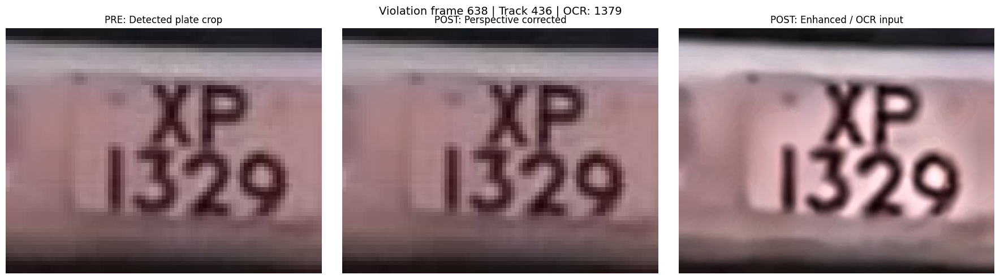

In [30]:
# ==============================
# PLATE PROCESSING PRE / POST OUTPUT
# ==============================
# Shows every plate-processing stage for every violation: raw -> corrected -> enhanced -> OCR.

def _show_img(ax, image, title):
    if image is None or getattr(image, 'size', 0) == 0:
        ax.text(0.5, 0.5, 'NO OUTPUT', ha='center', va='center', fontsize=12)
        ax.axis('off')
        ax.set_title(title)
        return
    if len(image.shape) == 3:
        ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    else:
        ax.imshow(image, cmap='gray')
    ax.axis('off')
    ax.set_title(title)

def show_plate_processing(record):
    ev = record.get('evidence', {})
    raw = cv2.imread(ev['plate_crop']) if ev.get('plate_crop') else None
    corrected = cv2.imread(ev['plate_corrected']) if ev.get('plate_corrected') else None
    enhanced = cv2.imread(ev['plate_enhanced']) if ev.get('plate_enhanced') else None

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    _show_img(axes[0], raw, 'PRE: Detected plate crop')
    _show_img(axes[1], corrected, 'POST: Perspective corrected')
    _show_img(axes[2], enhanced, 'POST: Enhanced / OCR input')
    fig.suptitle(
        f"Violation frame {record.get('frame')} | Track {record.get('track_id')} | "
        f"OCR: {(record.get('ocr') or {}).get('text') or 'NOT READ'}",
        fontsize=14
    )
    plt.tight_layout()
    plt.show()

# Display one complete pre/post pipeline per processed violation.
for item in plate_results:
    if (item.get('plate_detection') or {}).get('detected'):
        show_plate_processing(item)
    else:
        print(f"Frame {item.get('frame')} | Track {item.get('track_id')}: NO PLATE DETECTED")


In [31]:
# Helper for all plate-processing PRE/POST displays
def show_pair(images, titles, subtitle="", figsize=None):
    n = len(images)
    if figsize is None: figsize = (7*n, 5)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1: axes = [axes]
    for ax, img, title in zip(axes, images, titles):
        _show_img(ax, img, title)
    if subtitle:
        fig.suptitle(subtitle, fontsize=13)
    plt.tight_layout()
    plt.show()

def load_evidence_image(record, key):
    path = (record.get("evidence") or {}).get(key)
    return cv2.imread(path) if path else None


## Plate Processing — PRE / POST: Plate Detection
**Output of this stage:** original violation frame with the detected plate region → cropped plate.

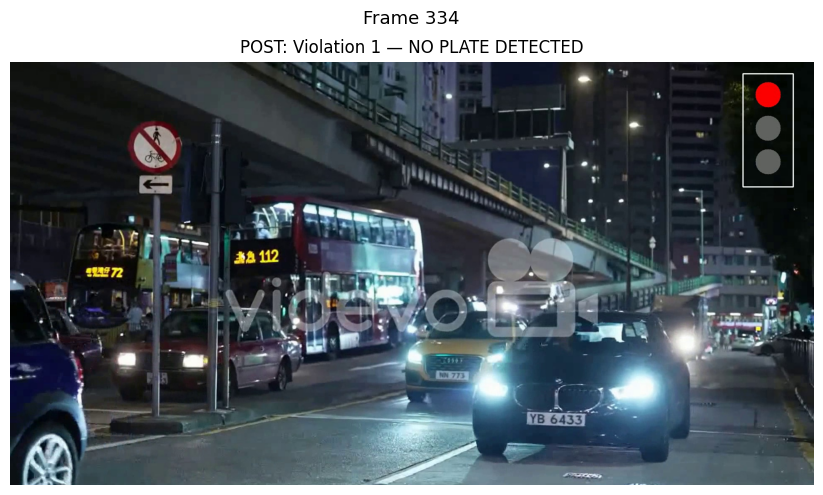

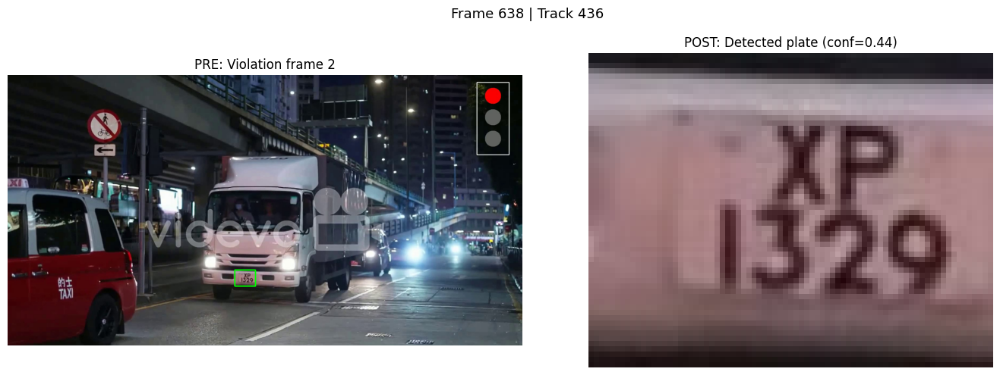

In [32]:
# PLATE DETECTION OUTPUT — one result for every processed violation
for i, record in enumerate(plate_results, 1):
    frame = load_evidence_image(record, "original_frame")
    plate = load_evidence_image(record, "plate_crop")
    det = record.get("plate_detection") or {}
    if frame is None:
        continue
    annotated = frame.copy()
    bbox = det.get("bbox")
    if bbox:
        x1,y1,x2,y2 = map(int,bbox)
        cv2.rectangle(annotated,(x1,y1),(x2,y2),(0,255,0),4)
    if plate is None:
        show_pair([annotated], [f"POST: Violation {i} — NO PLATE DETECTED"], f"Frame {record.get('frame')}", (9,5))
    else:
        show_pair([annotated, plate], [f"PRE: Violation frame {i}", f"POST: Detected plate (conf={det.get('confidence',0):.2f})"], f"Frame {record.get('frame')} | Track {record.get('track_id')}")


## Plate Processing — PRE / POST: Perspective Correction
**Output of this stage:** raw plate crop → perspective-corrected plate.

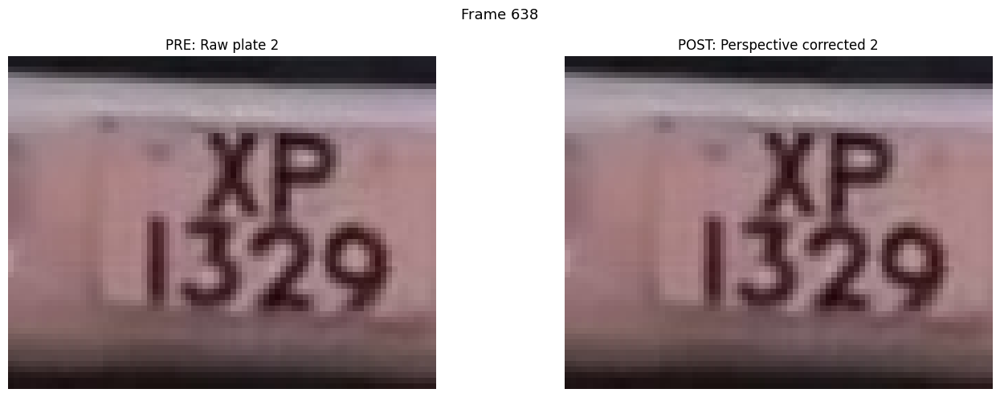

In [33]:
# PERSPECTIVE CORRECTION OUTPUT — one result for every detected plate
for i, record in enumerate(plate_results, 1):
    raw = load_evidence_image(record, "plate_crop")
    corrected = load_evidence_image(record, "plate_corrected")
    if raw is None: continue
    if corrected is None: corrected = perspective_correct_plate(raw)
    show_pair([raw, corrected], [f"PRE: Raw plate {i}", f"POST: Perspective corrected {i}"], f"Frame {record.get('frame')}")


## Plate Processing — PRE / POST: Image Enhancement
**Output of this stage:** corrected plate → enhanced plate used by OCR.

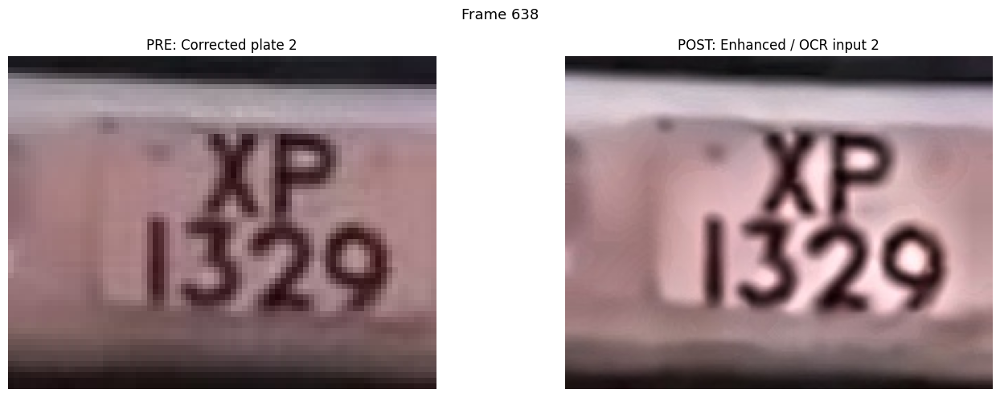

In [34]:
# IMAGE ENHANCEMENT OUTPUT — one result for every detected plate
for i, record in enumerate(plate_results, 1):
    corrected = load_evidence_image(record, "plate_corrected")
    enhanced = load_evidence_image(record, "plate_enhanced")
    if corrected is None: continue
    if enhanced is None: enhanced = enhance_plate(corrected)
    show_pair([corrected, enhanced], [f"PRE: Corrected plate {i}", f"POST: Enhanced / OCR input {i}"], f"Frame {record.get('frame')}")


## Plate Processing — PRE / POST: OCR
**Output of this stage:** enhanced plate → recognized registration text + confidence.

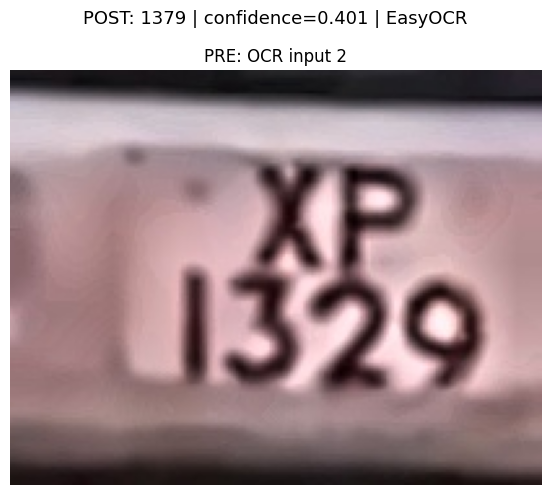

Plate 2: 1379 | confidence=0.401 | backend=EasyOCR


In [35]:
# OCR OUTPUT — one result for every detected plate
for i, record in enumerate(plate_results, 1):
    enhanced = load_evidence_image(record, "plate_enhanced")
    if enhanced is None: continue
    ocr = record.get("ocr") or {}
    text = ocr.get("text") or "NOT READ"
    confidence = float(ocr.get("confidence", 0.0))
    backend = ocr.get("backend", "UNKNOWN")
    show_pair([enhanced], [f"PRE: OCR input {i}"], f"POST: {text} | confidence={confidence:.3f} | {backend}", (8,5))
    print(f"Plate {i}: {text} | confidence={confidence:.3f} | backend={backend}")


## Plate Processing — PRE / POST: Validation
**Output of this stage:** OCR result → VALID / REVIEW with individual validation checks.

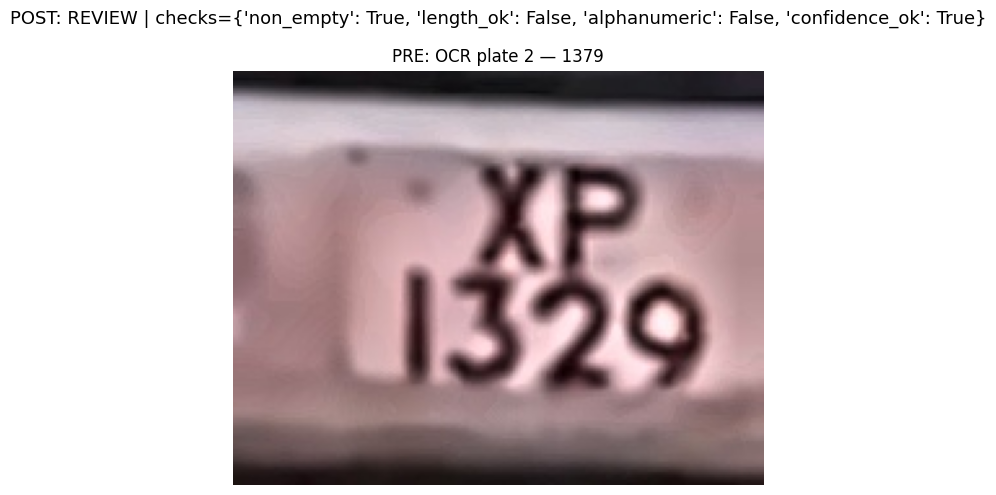

Plate 2: REVIEW | {'non_empty': True, 'length_ok': False, 'alphanumeric': False, 'confidence_ok': True}


In [36]:
# VALIDATION OUTPUT — one result for every detected plate
for i, record in enumerate(plate_results, 1):
    enhanced = load_evidence_image(record, "plate_enhanced")
    if enhanced is None: continue
    ocr = record.get("ocr") or {}
    validation = record.get("validation") or {}
    text = ocr.get("text") or "NOT READ"
    status = "VALID" if validation.get("valid") else "REVIEW"
    checks = validation.get("checks", {})
    show_pair([enhanced], [f"PRE: OCR plate {i} — {text}"], f"POST: {status} | checks={checks}", (9,5))
    print(f"Plate {i}: {status} | {checks}")


In [37]:
# ==============================
# FINAL JSON + CSV EXPORT
# ==============================

final_json = OUTPUT_DIR / "final_violation_evidence.json"
with open(final_json, "w") as f:
    json.dump(plate_results, f, indent=2)

# Flat summary for quick inspection.
summary_rows = []
for item in plate_results:
    summary_rows.append({
        "frame": item.get("frame"),
        "track_id": item.get("track_id"),
        "plate": (item.get("ocr") or {}).get("text", ""),
        "ocr_confidence": (item.get("ocr") or {}).get("confidence", 0.0),
        "plate_valid": (item.get("validation") or {}).get("valid", False),
        "plate_detection_confidence": (item.get("plate_detection") or {}).get("confidence", 0.0),
        "evidence_dir": (item.get("evidence") or {}).get("directory", ""),
    })

summary_csv = OUTPUT_DIR / "violation_summary.csv"
import pandas as pd
pd.DataFrame(summary_rows).to_csv(summary_csv, index=False)

print("Final evidence JSON:", final_json)
print("Summary CSV:", summary_csv)


Final evidence JSON: /kaggle/working/signal_evidence/final_violation_evidence.json
Summary CSV: /kaggle/working/signal_evidence/violation_summary.csv


## 14. Final review

The resulting evidence directory contains one folder per confirmed red-light violation. A plate that fails validation is retained for manual review rather than silently discarded.


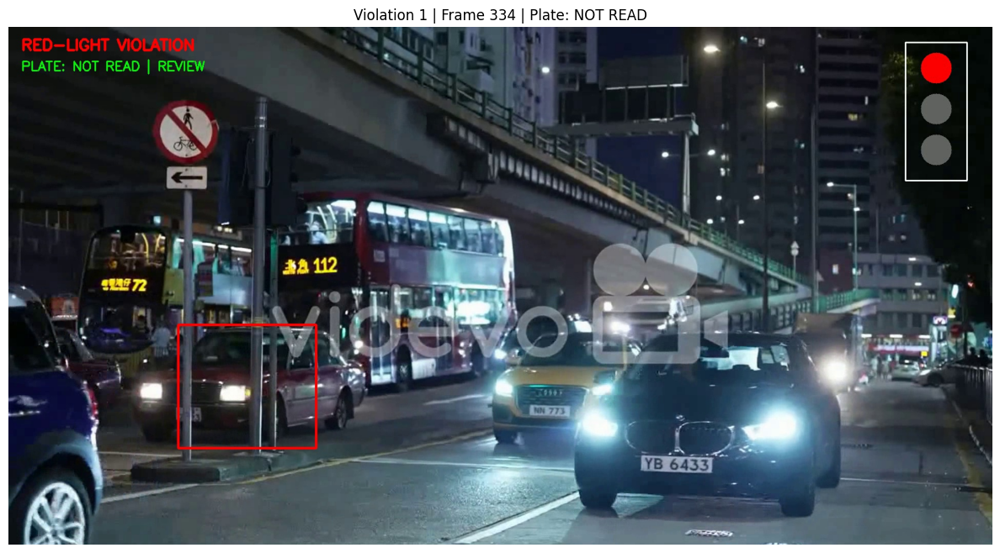

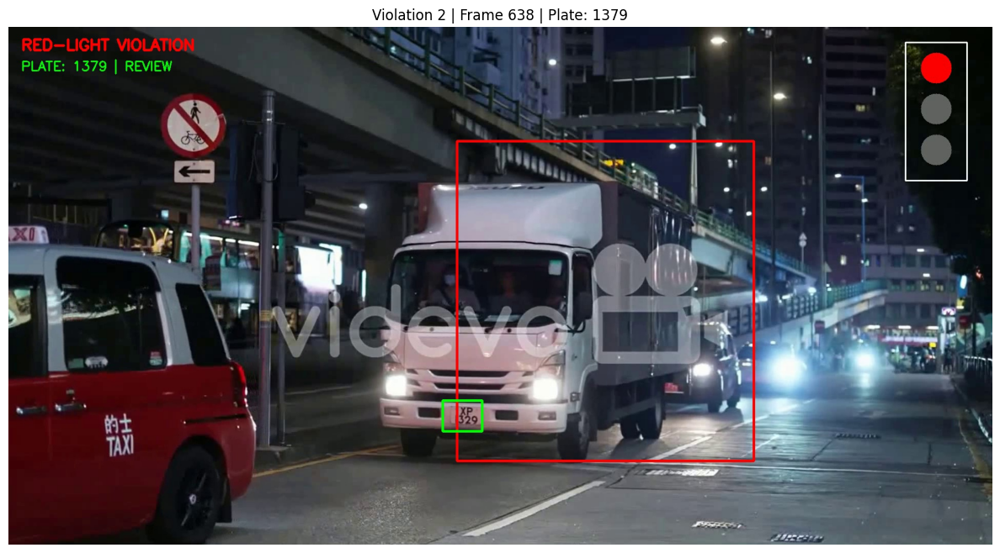

In [38]:
# Display the final evidence frames.
for i, item in enumerate(plate_results, start=1):
    path = item.get("evidence", {}).get("evidence_frame")
    if path and Path(path).exists():
        image = cv2.imread(path)
        plt.figure(figsize=(16, 8))
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.title(
            f"Violation {i} | Frame {item['frame']} | "
            f"Plate: {(item.get('ocr') or {}).get('text', 'NOT READ')}"
        )
        plt.axis("off")
        plt.show()
